In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv("C:/Users/USER/Downloads/sales_data_sample.csv", encoding='latin1')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()
# Display data types and basic info
print("Data Types and Non-null Counts:")
df.info()

print("\nUnique values in categorical columns:")
categorical_cols = ['STATUS', 'PRODUCTLINE', 'COUNTRY', 'DEALSIZE']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(f"Values: {df[col].unique()[:10]}")  # Show first 10 unique values
    print()


Dataset Shape: (2823, 25)

Column Names:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

First 5 rows:
Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8

Data Cleaning

Missing Values:
ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

Duplicate rows: 0

After cleaning - Missing values:
5157

Final dataset shape: (2823, 28)


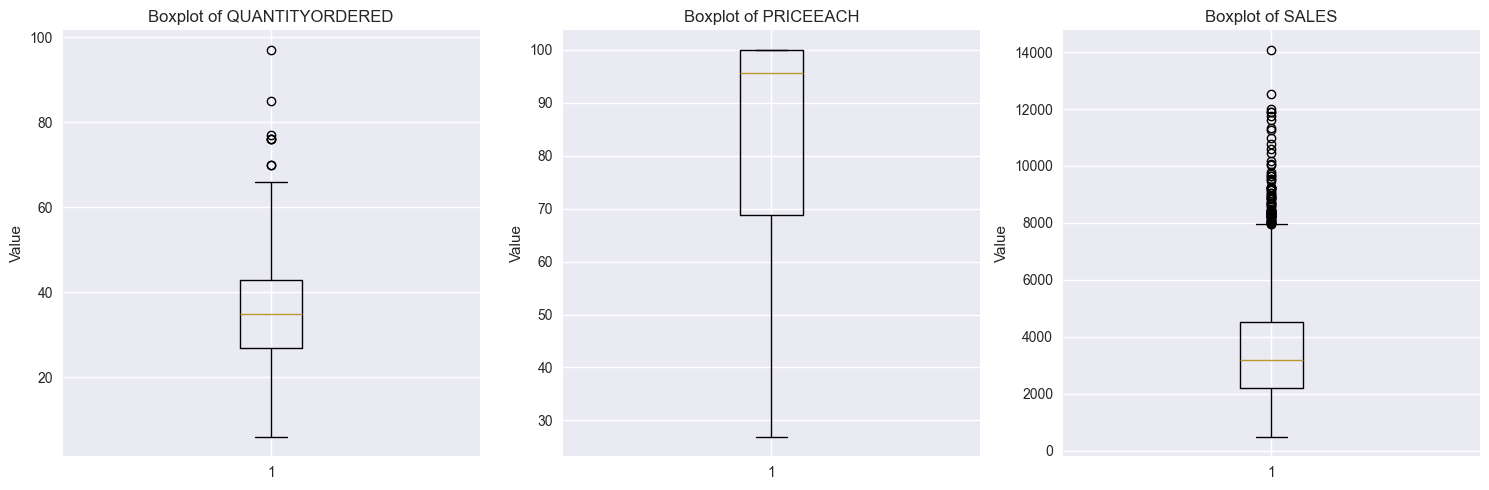

Statistical Summary:
Dataset Overview:
Total Orders: 2,823
Date Range: 2003-01-06 00:00:00 to 2005-05-31 00:00:00
Total Sales: $10,032,628.85
Average Order Value: $3553.89
Number of Products: 109
Number of Customers: 92
Number of Countries: 19


In [7]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Convert date columns to datetime
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# Create new features from date
df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month
df['DAY'] = df['ORDERDATE'].dt.day

# Handle any remaining missing values (if any)
print("\nAfter cleaning - Missing values:")
print(df.isnull().sum().sum())

# Remove any rows with missing critical values
df = df.dropna(subset=['SALES', 'QUANTITYORDERED', 'PRICEEACH'])

print(f"\nFinal dataset shape: {df.shape}")
# Check for outliers in numerical columns
numerical_cols = ['QUANTITYORDERED', 'PRICEEACH', 'SALES']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

# Statistical summary
print("Statistical Summary:")
df[numerical_cols].describe()
# Comprehensive statistical summary
print("Dataset Overview:")
print(f"Total Orders: {df.shape[0]:,}")
print(f"Date Range: {df['ORDERDATE'].min()} to {df['ORDERDATE'].max()}")
print(f"Total Sales: ${df['SALES'].sum():,.2f}")
print(f"Average Order Value: ${df['SALES'].mean():.2f}")
print(f"Number of Products: {df['PRODUCTCODE'].nunique()}")
print(f"Number of Customers: {df['CUSTOMERNAME'].nunique()}")
print(f"Number of Countries: {df['COUNTRY'].nunique()}")


: Sales by Product Line

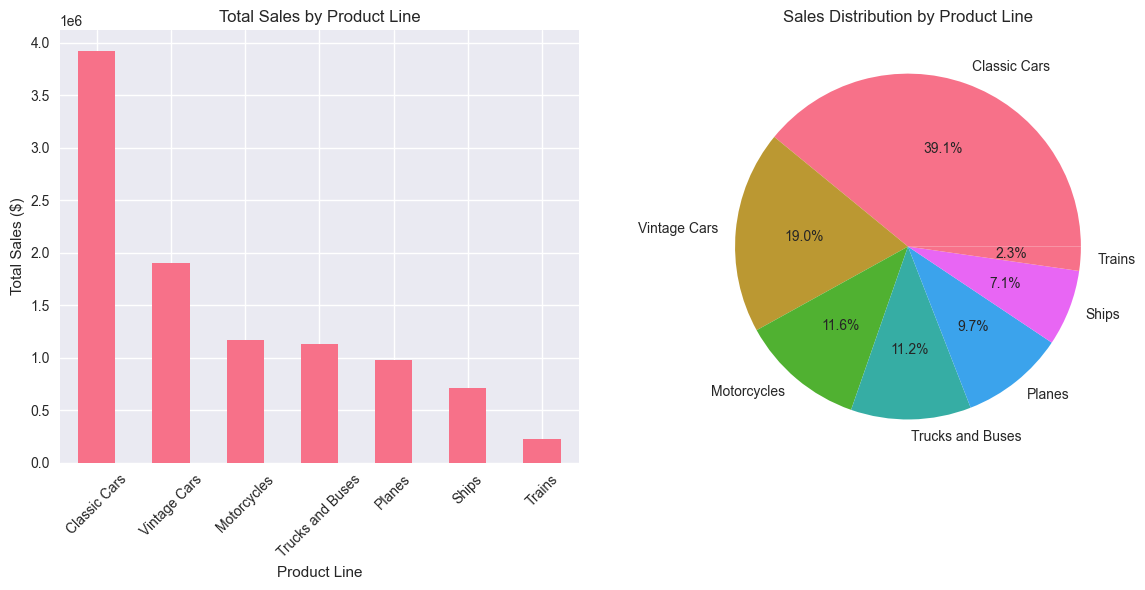

Sales by Product Line:
Classic Cars: $3,919,615.66
Vintage Cars: $1,903,150.84
Motorcycles: $1,166,388.34
Trucks and Buses: $1,127,789.84
Planes: $975,003.57
Ships: $714,437.13
Trains: $226,243.47


In [8]:
plt.figure(figsize=(12, 6))
sales_by_product = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

plt.subplot(1, 2, 1)
sales_by_product.plot(kind='bar')
plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(sales_by_product.values, labels=sales_by_product.index, autopct='%1.1f%%')
plt.title('Sales Distribution by Product Line')

plt.tight_layout()
plt.show()

print("Sales by Product Line:")
for product, sales in sales_by_product.items():
    print(f"{product}: ${sales:,.2f}")


Sales by Country (Top 10)

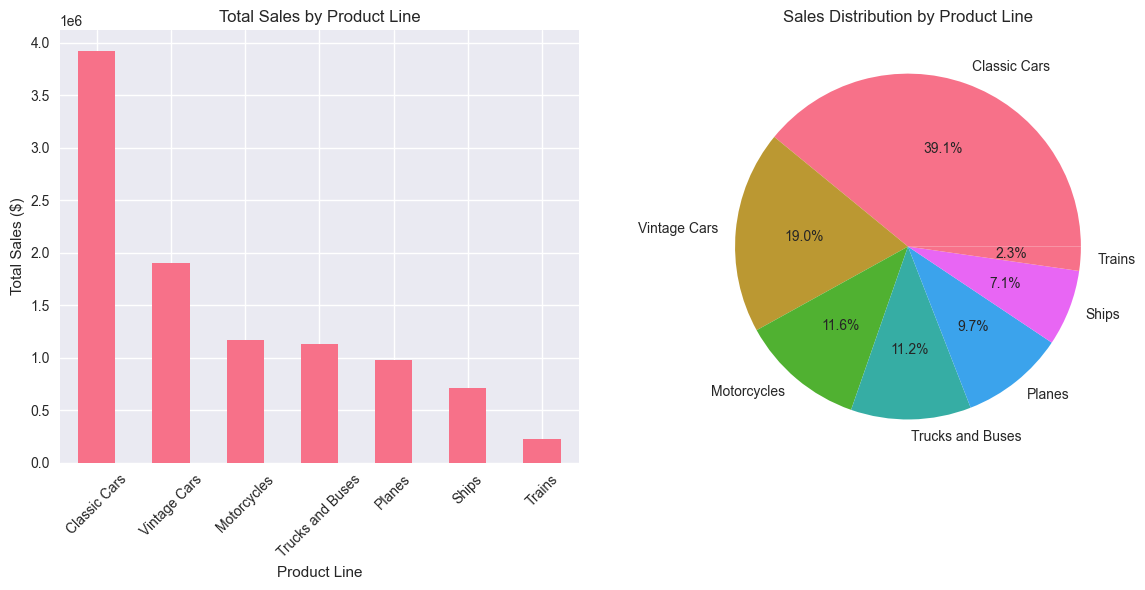

Sales by Product Line:
Classic Cars: $3,919,615.66
Vintage Cars: $1,903,150.84
Motorcycles: $1,166,388.34
Trucks and Buses: $1,127,789.84
Planes: $975,003.57
Ships: $714,437.13
Trains: $226,243.47


In [9]:
plt.figure(figsize=(12, 6))
sales_by_product = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

plt.subplot(1, 2, 1)
sales_by_product.plot(kind='bar')
plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(sales_by_product.values, labels=sales_by_product.index, autopct='%1.1f%%')
plt.title('Sales Distribution by Product Line')

plt.tight_layout()
plt.show()

print("Sales by Product Line:")
for product, sales in sales_by_product.items():
    print(f"{product}: ${sales:,.2f}")


Monthly Sales Trend

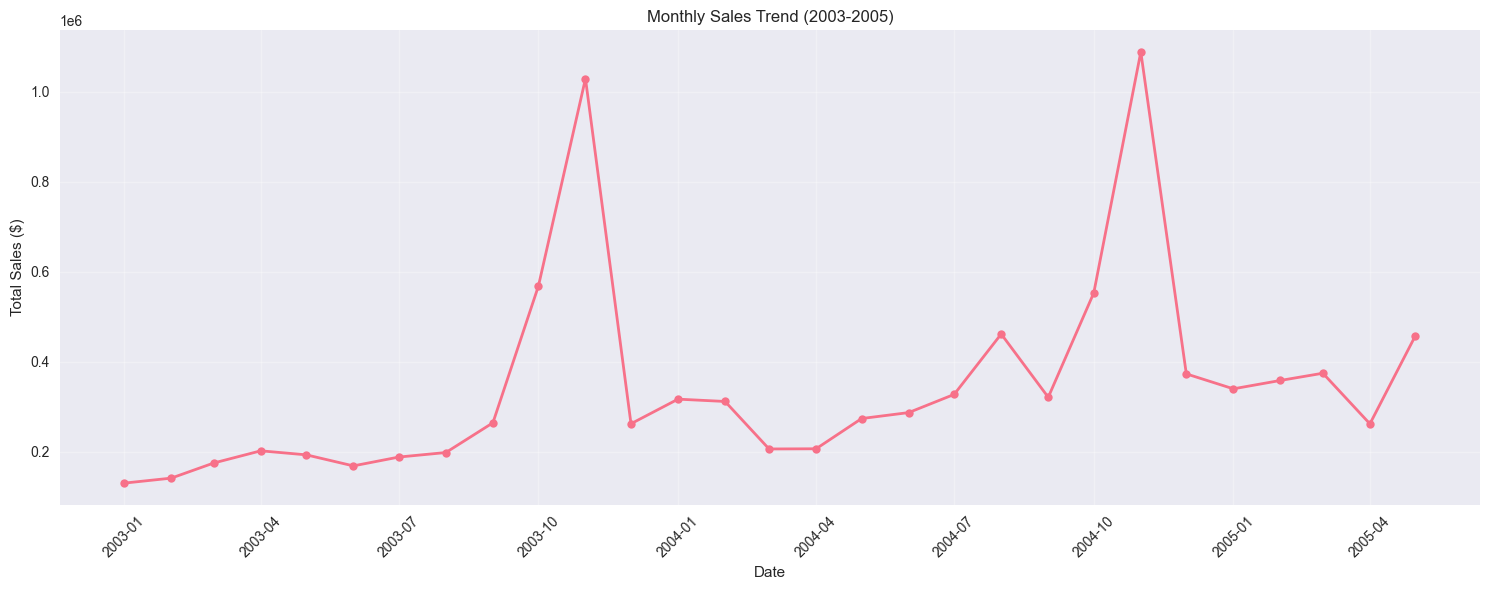

Top 5 Months by Sales:
2004-11: $1,089,048.01
2003-11: $1,029,837.66
2003-10: $568,290.97
2004-10: $552,924.25
2004-08: $461,501.27


In [10]:
plt.figure(figsize=(15, 6))
monthly_sales = df.groupby(['YEAR', 'MONTH'])['SALES'].sum().reset_index()
monthly_sales['DATE'] = pd.to_datetime(monthly_sales[['YEAR', 'MONTH']].assign(DAY=1))

plt.plot(monthly_sales['DATE'], monthly_sales['SALES'], marker='o', linewidth=2, markersize=6)
plt.title('Monthly Sales Trend (2003-2005)')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identify peak months
print("Top 5 Months by Sales:")
top_months = monthly_sales.nlargest(5, 'SALES')
for _, row in top_months.iterrows():
    print(f"{row['YEAR']}-{row['MONTH']:02d}: ${row['SALES']:,.2f}")


Sales by Deal Size

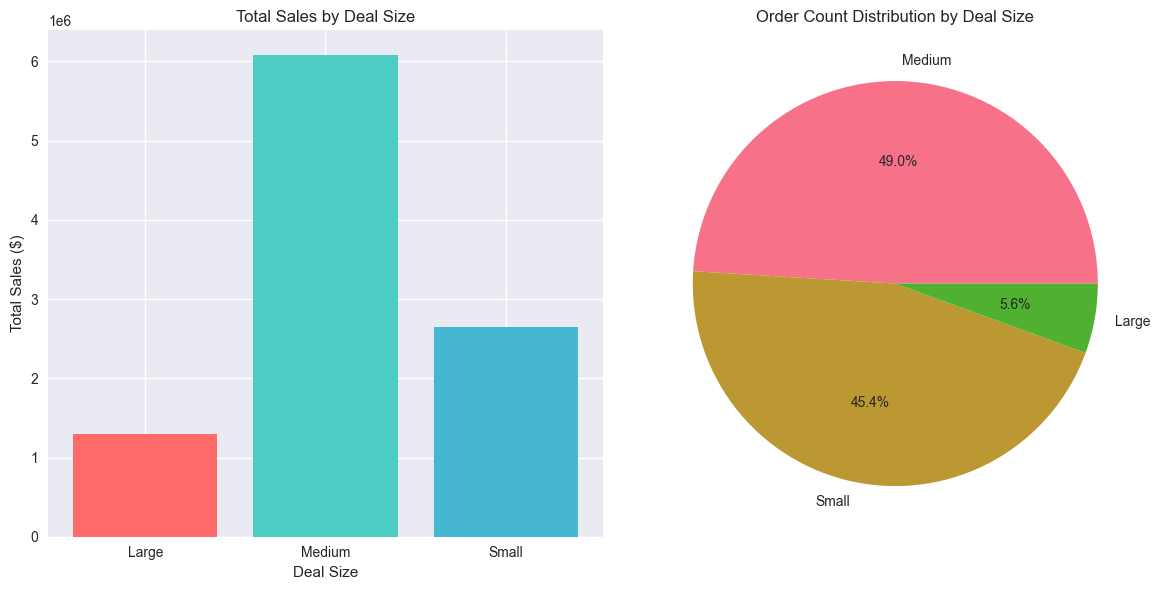

In [11]:
plt.figure(figsize=(12, 6))
sales_by_dealsize = df.groupby('DEALSIZE')['SALES'].sum()

plt.subplot(1, 2, 1)
plt.bar(sales_by_dealsize.index, sales_by_dealsize.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Total Sales by Deal Size')
plt.xlabel('Deal Size')
plt.ylabel('Total Sales ($)')

plt.subplot(1, 2, 2)
order_count_by_dealsize = df['DEALSIZE'].value_counts()
plt.pie(order_count_by_dealsize.values, labels=order_count_by_dealsize.index, autopct='%1.1f%%')
plt.title('Order Count Distribution by Deal Size')

plt.tight_layout()
plt.show()


Price vs Quantity Relationship

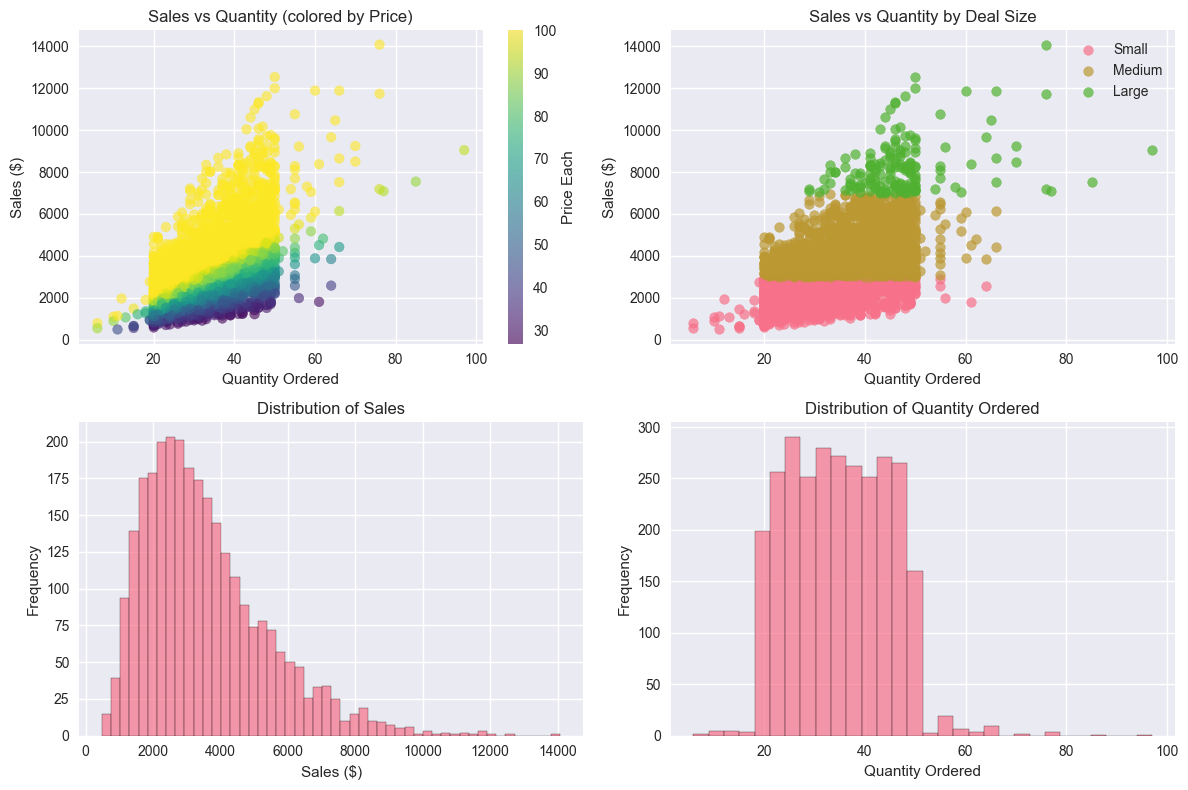

In [12]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.scatter(df['QUANTITYORDERED'], df['SALES'], alpha=0.6, c=df['PRICEEACH'], cmap='viridis')
plt.colorbar(label='Price Each')
plt.xlabel('Quantity Ordered')
plt.ylabel('Sales ($)')
plt.title('Sales vs Quantity (colored by Price)')

plt.subplot(2, 2, 2)
for dealsize in df['DEALSIZE'].unique():
    subset = df[df['DEALSIZE'] == dealsize]
    plt.scatter(subset['QUANTITYORDERED'], subset['SALES'], label=dealsize, alpha=0.7)
plt.xlabel('Quantity Ordered')
plt.ylabel('Sales ($)')
plt.title('Sales vs Quantity by Deal Size')
plt.legend()

plt.subplot(2, 2, 3)
plt.hist(df['SALES'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')

plt.subplot(2, 2, 4)
plt.hist(df['QUANTITYORDERED'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Quantity Ordered')
plt.ylabel('Frequency')
plt.title('Distribution of Quantity Ordered')

plt.tight_layout()
plt.show()


Correlation Heatmap


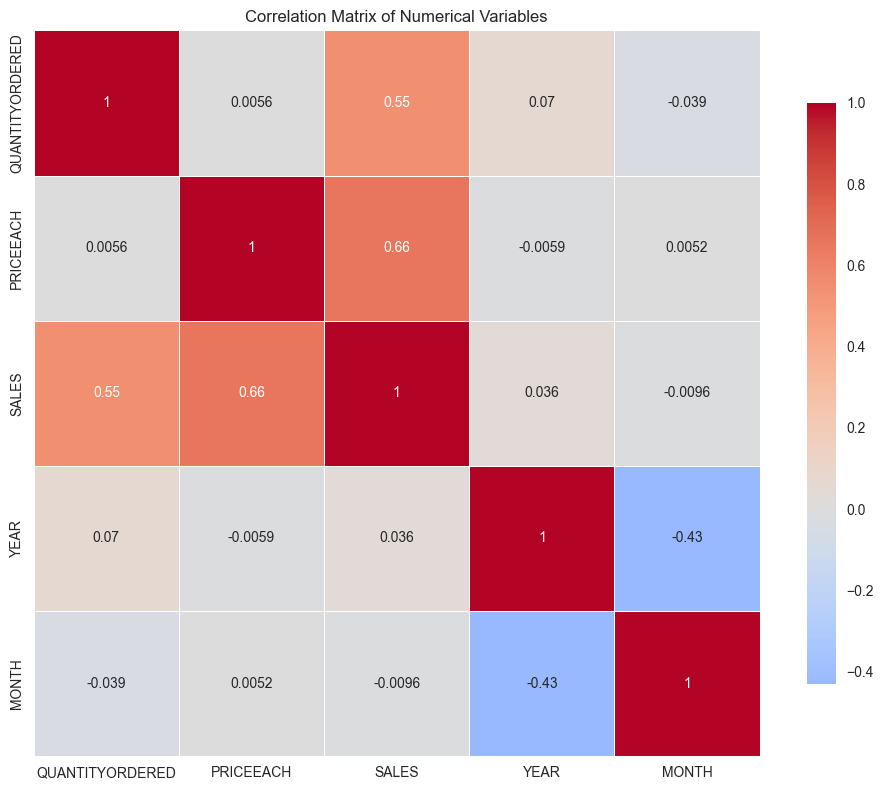

Correlation Analysis:
Strong correlations (>0.7 or <-0.7):


In [13]:
# Select numerical columns for correlation
correlation_cols = ['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'YEAR', 'MONTH']
correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

print("Correlation Analysis:")
print("Strong correlations (>0.7 or <-0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"{correlation_matrix.columns[i]} vs {correlation_matrix.columns[j]}: {corr_val:.3f}")


. Feature Engineering

In [14]:
# Create additional features
df['REVENUE_PER_UNIT'] = df['SALES'] / df['QUANTITYORDERED']
df['ORDER_MONTH_NAME'] = df['ORDERDATE'].dt.month_name()
df['QUARTER'] = df['ORDERDATE'].dt.quarter
df['IS_WEEKEND'] = df['ORDERDATE'].dt.weekday >= 5

# Create seasonal features
df['SEASON'] = df['MONTH'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                3: 'Spring', 4: 'Spring', 5: 'Spring',
                                6: 'Summer', 7: 'Summer', 8: 'Summer',
                                9: 'Fall', 10: 'Fall', 11: 'Fall'})

# Encode categorical variables for modeling
label_encoders = {}
categorical_features = ['PRODUCTLINE', 'DEALSIZE', 'COUNTRY', 'STATUS', 'SEASON']

df_encoded = df.copy()
for feature in categorical_features:
    le = LabelEncoder()
    df_encoded[feature + '_ENCODED'] = le.fit_transform(df[feature])
    label_encoders[feature] = le

print("Feature Engineering Complete!")
print("New features created:")
print("- REVENUE_PER_UNIT")
print("- ORDER_MONTH_NAME")
print("- QUARTER")
print("- IS_WEEKEND")
print("- SEASON")
print("- Encoded categorical variables")


Feature Engineering Complete!
New features created:
- REVENUE_PER_UNIT
- ORDER_MONTH_NAME
- QUARTER
- IS_WEEKEND
- SEASON
- Encoded categorical variables


Predictive Modeling

In [15]:
 # Prepare features for modeling
feature_columns = [
    'QUANTITYORDERED', 'PRICEEACH', 'YEAR', 'MONTH', 'QUARTER',
    'PRODUCTLINE_ENCODED', 'DEALSIZE_ENCODED', 'COUNTRY_ENCODED'
]

X = df_encoded[feature_columns]
y = df_encoded['SALES']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 2258 samples
Test set size: 565 samples


Model 1: Linear Regression

In [16]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# Evaluation metrics
lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)
lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

print("Linear Regression Results:")
print(f"Training R²: {lr_train_r2:.4f}")
print(f"Test R²: {lr_test_r2:.4f}")
print(f"Training MAE: ${lr_train_mae:.2f}")
print(f"Test MAE: ${lr_test_mae:.2f}")
print(f"Training RMSE: ${np.sqrt(lr_train_mse):.2f}")
print(f"Test RMSE: ${np.sqrt(lr_test_mse):.2f}")


Linear Regression Results:
Training R²: 0.8386
Test R²: 0.7997
Training MAE: $510.96
Test MAE: $605.17
Training RMSE: $712.21
Test RMSE: $935.03


Model 2: Random Forest

In [17]:
# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Evaluation metrics
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Results:")
print(f"Training R²: {rf_train_r2:.4f}")
print(f"Test R²: {rf_test_r2:.4f}")
print(f"Training MAE: ${rf_train_mae:.2f}")
print(f"Test MAE: ${rf_test_mae:.2f}")
print(f"Training RMSE: ${np.sqrt(rf_train_mse):.2f}")
print(f"Test RMSE: ${np.sqrt(rf_test_mse):.2f}")


Random Forest Results:
Training R²: 0.9648
Test R²: 0.8902
Training MAE: $184.36
Test MAE: $331.96
Training RMSE: $332.55
Test RMSE: $692.14


Model Comparison (Test Set Performance):
     Metric  Linear Regression  Random Forest
0  R² Score             0.7997         0.8902
1       MAE           605.1688       331.9588
2      RMSE           935.0279       692.1395


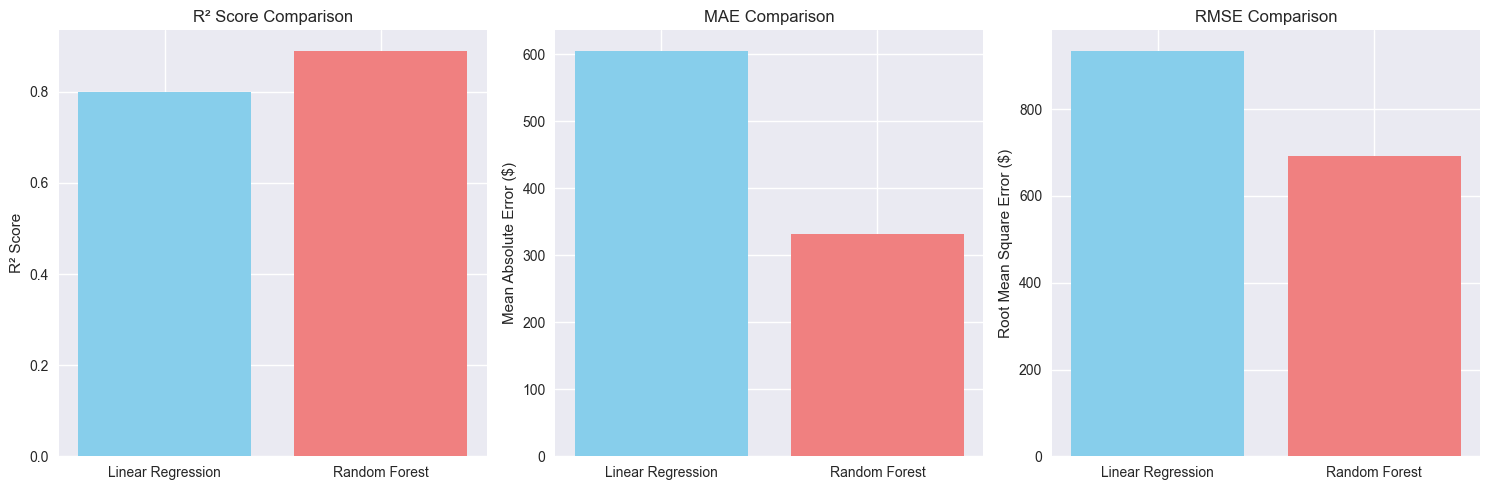

In [18]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'RMSE'],
    'Linear Regression': [lr_test_r2, lr_test_mae, np.sqrt(lr_test_mse)],
    'Random Forest': [rf_test_r2, rf_test_mae, np.sqrt(rf_test_mse)]
})

print("Model Comparison (Test Set Performance):")
print(comparison_df.round(4))

# Visualize model comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_test_r2, rf_test_r2]
plt.bar(models, r2_scores, color=['skyblue', 'lightcoral'])
plt.title('R² Score Comparison')
plt.ylabel('R² Score')

plt.subplot(1, 3, 2)
mae_scores = [lr_test_mae, rf_test_mae]
plt.bar(models, mae_scores, color=['skyblue', 'lightcoral'])
plt.title('MAE Comparison')
plt.ylabel('Mean Absolute Error ($)')

plt.subplot(1, 3, 3)
rmse_scores = [np.sqrt(lr_test_mse), np.sqrt(rf_test_mse)]
plt.bar(models, rmse_scores, color=['skyblue', 'lightcoral'])
plt.title('RMSE Comparison')
plt.ylabel('Root Mean Square Error ($)')

plt.tight_layout()
plt.show()


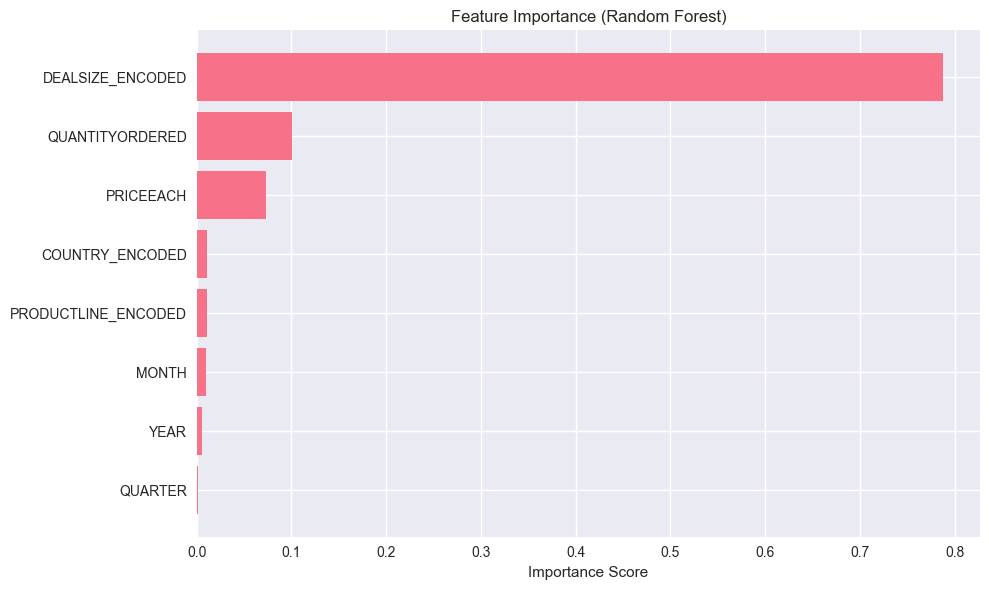

Feature Importance Rankings:
DEALSIZE_ENCODED: 0.7875
QUANTITYORDERED: 0.1010
PRICEEACH: 0.0726
COUNTRY_ENCODED: 0.0113
PRODUCTLINE_ENCODED: 0.0106
MONTH: 0.0097
YEAR: 0.0054
QUARTER: 0.0018


In [19]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature Importance Rankings:")
for _, row in feature_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


Model Performance Visualization

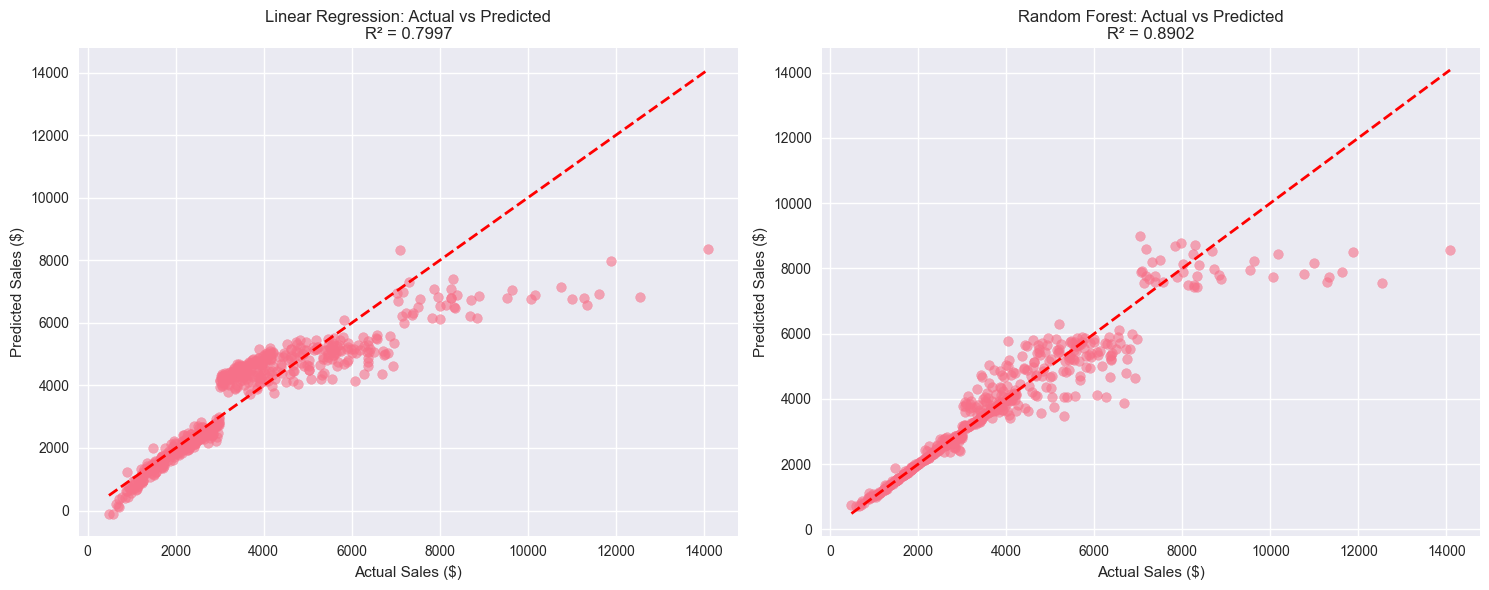

In [20]:
# Prediction vs Actual plots
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title(f'Linear Regression: Actual vs Predicted\nR² = {lr_test_r2:.4f}')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title(f'Random Forest: Actual vs Predicted\nR² = {rf_test_r2:.4f}')

plt.tight_layout()
plt.show()
